In [5]:
# Tiny-ImageNet 직접 다운로드 (Add Data 불필요, Internet: On 필요)
import os
if not os.path.exists('/kaggle/working/tiny-imagenet-200'):
    print("⬇️ Tiny-ImageNet 다운로드 중... (248MB, 1~2분)")
    !wget -q http://cs231n.stanford.edu/tiny-imagenet-200.zip -P /kaggle/working/
    !unzip -q /kaggle/working/tiny-imagenet-200.zip -d /kaggle/working/
    print("✅ 완료")


# ==========================================
# 1. 데이터 준비 — Tiny-ImageNet(마운트) + CIFAR-10(다운로드)
# ==========================================
import os, time, tarfile, urllib.request
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 장치: {device}")
if device.type == 'cuda':
    print(f"   {torch.cuda.get_device_name(0)}\n")

# ---- Tiny-ImageNet 루트 자동 탐색 ----
def find_tiny_imagenet(base='/kaggle/input'):
    """Add Data로 추가한 데이터셋의 폴더명이 제각각이라 구조로 찾는다."""
    if not os.path.isdir(base):
        return None
    for root, dirs, files in os.walk(base):
        if 'wnids.txt' in files and 'train' in dirs and 'val' in dirs:
            return root
    return None

TIN_ROOT = find_tiny_imagenet('/kaggle')
if TIN_ROOT is None:
    raise FileNotFoundError(
        "Tiny-ImageNet을 찾지 못했습니다.\n"
        "우측 패널 Add Data → 'tiny imagenet' 검색 → 데이터셋을 추가하세요.\n"
        "(train/, val/, wnids.txt 를 포함한 데이터셋이어야 합니다)")
print(f"📂 Tiny-ImageNet: {TIN_ROOT}")

# ---- CIFAR-10 다운로드 (Settings > Internet: On 필요) ----
cifar_tgz = '/kaggle/working/cifar10.tgz'
cifar_dir = '/kaggle/working/cifar10'
if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tgz):
        print("⬇️ CIFAR-10 다운로드 중...")
        urllib.request.urlretrieve(
            'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz', cifar_tgz)
    print("📦 압축 해제 중...")
    with tarfile.open(cifar_tgz, 'r:gz') as tar:
        tar.extractall(path='/kaggle/working/')
print(f"📂 CIFAR-10: {cifar_dir}\n")



⬇️ Tiny-ImageNet 다운로드 중... (248MB, 1~2분)
✅ 완료
🖥️ 장치: cuda
   Tesla T4

📂 Tiny-ImageNet: /kaggle/working/tiny-imagenet-200
⬇️ CIFAR-10 다운로드 중...
📦 압축 해제 중...


/tmp/ipykernel_58/372000404.py:54: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/kaggle/working/')


📂 CIFAR-10: /kaggle/working/cifar10



In [6]:
# ==========================================
# 2. Dataset / DataLoader
# ==========================================
IMG_SIZE = 64      # ViT 입력 해상도. CIFAR-10(32)도 여기에 맞춰 리사이즈한다.
                   # → 사전학습 backbone(patch_embed, pos_embed)을 그대로 재사용 가능

TIN_MEAN, TIN_STD = (0.4802, 0.4481, 0.3975), (0.2770, 0.2691, 0.2821)
C10_MEAN, C10_STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

class TinyImageNetVal(Dataset):
    """
    val 폴더는 클래스별로 나뉘어 있지 않고 val_annotations.txt에 매핑이 들어있다.
    /kaggle/input은 읽기 전용이라 파일을 옮길 수 없으므로, 매핑을 직접 읽어 처리한다.
    """
    def __init__(self, root, class_to_idx, transform=None):
        self.transform = transform
        self.samples = []
        with open(os.path.join(root, 'val', 'val_annotations.txt')) as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) < 2:
                    continue
                fname, wnid = parts[0], parts[1]
                if wnid in class_to_idx:
                    self.samples.append(
                        (os.path.join(root, 'val', 'images', fname), class_to_idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')   # 흑백 이미지가 섞여 있어 RGB 강제 변환
        if self.transform:
            img = self.transform(img)
        return img, label


def make_transforms(mean, std, train, strong_aug):
    if not train:
        return transforms.Compose([
            transforms.Resize(IMG_SIZE) if IMG_SIZE != 64 else transforms.Lambda(lambda x: x),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(), transforms.Normalize(mean, std)])
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE)),
           transforms.RandomCrop(IMG_SIZE, padding=IMG_SIZE // 8),
           transforms.RandomHorizontalFlip()]
    if strong_aug:
        # ViT는 inductive bias가 없어 강한 증강이 사실상 필수 (DeiT 계열 레시피)
        ops.append(transforms.RandAugment(num_ops=2, magnitude=9))
    ops += [transforms.ToTensor(), transforms.Normalize(mean, std)]
    return transforms.Compose(ops)


BATCH_SIZE = 256
NUM_WORKERS = 2

# ---- Tiny-ImageNet ----
tin_train = datasets.ImageFolder(os.path.join(TIN_ROOT, 'train'),
                                 transform=make_transforms(TIN_MEAN, TIN_STD, True, True))
tin_val = TinyImageNetVal(TIN_ROOT, tin_train.class_to_idx,
                          transform=make_transforms(TIN_MEAN, TIN_STD, False, False))
tin_train_loader = DataLoader(tin_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
tin_val_loader = DataLoader(tin_val, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

# ---- CIFAR-10 ----
c10_train = datasets.ImageFolder(os.path.join(cifar_dir, 'train'),
                                 transform=make_transforms(C10_MEAN, C10_STD, True, False))
c10_test = datasets.ImageFolder(os.path.join(cifar_dir, 'test'),
                                transform=make_transforms(C10_MEAN, C10_STD, False, False))
c10_train_loader = DataLoader(c10_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
c10_test_loader = DataLoader(c10_test, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

print(f"Tiny-ImageNet : train {len(tin_train):,} / val {len(tin_val):,} / "
      f"클래스 {len(tin_train.classes)}")
print(f"CIFAR-10      : train {len(c10_train):,} / test {len(c10_test):,} / "
      f"클래스 {len(c10_train.classes)}")
print(f"입력 해상도   : {IMG_SIZE}×{IMG_SIZE}\n")

Tiny-ImageNet : train 100,000 / val 10,000 / 클래스 200
CIFAR-10      : train 50,000 / test 10,000 / 클래스 10
입력 해상도   : 64×64



In [7]:
# ==========================================
# 3. ViT 정의
# ==========================================
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_ch=3, dim=192):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)   # B, N, dim


class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        return x + self.mlp(self.norm2(x))


class ViT(nn.Module):
    """작은 ViT (ViT-Tiny 급). 64x64 / patch 8 → 64 토큰 + cls = 65"""
    def __init__(self, img_size=64, patch_size=8, num_classes=200,
                 dim=192, depth=6, heads=3, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, dim)
        n = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, dim))
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward_features(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)[:, 0]

    def forward(self, x):
        return self.head(self.forward_features(x))


VIT_CFG = dict(img_size=IMG_SIZE, patch_size=8, dim=192, depth=6, heads=3,
               mlp_ratio=4.0, drop=0.1)

def build_vit(num_classes):
    return ViT(num_classes=num_classes, **VIT_CFG).to(device)


def load_backbone(model, state_dict, verbose=True):
    """head를 제외한 backbone만 이식 (200클래스 → 10클래스 전이용)"""
    backbone = {k: v for k, v in state_dict.items() if not k.startswith('head.')}
    missing, unexpected = model.load_state_dict(backbone, strict=False)
    if verbose:
        print(f"   backbone 이식 완료 (새로 초기화된 파라미터: {missing})")
    return model

_m = build_vit(200)
print(f"✅ ViT 정의 완료 — {sum(p.numel() for p in _m.parameters()):,} params, "
      f"토큰 {_m.patch_embed.num_patches + 1}개\n")
del _m

✅ ViT 정의 완료 — 2,757,896 params, 토큰 65개



In [8]:
# ==========================================
# 4. Lion + SAMAscent
# ==========================================
class Lion(optim.Optimizer):
    """
    update = sign(β₁·m + (1-β₁)·g)   /   m = β₂·m + (1-β₂)·g
    ⚠️ lr은 AdamW의 1/3~1/10, weight_decay는 3~10배가 정석
    """
    def __init__(self, params, lr=2e-4, betas=(0.9, 0.99), weight_decay=0.5):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            lr, wd = group['lr'], group['weight_decay']
            b1, b2 = group['betas']
            for p in group['params']:
                if p.grad is None:
                    continue
                st = self.state[p]
                if 'exp_avg' not in st:
                    st['exp_avg'] = torch.zeros_like(p)
                m, g = st['exp_avg'], p.grad
                if wd != 0:
                    p.mul_(1 - lr * wd)
                p.add_(m.mul(b1).add_(g, alpha=1 - b1).sign_(), alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss


class SAMAscent:
    """
    SAM을 '옵티마이저'가 아니라 '그래디언트 변환기'로 분리.
    옵티마이저를 교체하지 않으므로 모멘텀 상태가 완벽히 연속된다.
    """
    def __init__(self, params, rho=0.0):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho
        self._e_w = {}

    def set_rho(self, rho):
        self.rho = rho

    @torch.no_grad()
    def ascent(self):
        if self.rho <= 0:
            return False
        grads = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        if not grads:
            return False
        gn = torch.norm(torch.stack(grads), p=2)
        if gn.item() < 1e-12:
            return False
        scale = self.rho / (gn + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None:
                continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self._e_w[p] = e_w
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self._e_w.items():
            p.sub_(e_w)
        self._e_w.clear()

print("✅ Lion + SAMAscent 정의 완료!\n")

✅ Lion + SAMAscent 정의 완료!



In [9]:
# ==========================================
# 5. WSD 스케줄 + 학습 루프 + 진단
# ==========================================
import math

def wsd_lr(epoch, total_epochs, peak_lr, warmup_epochs, decay_epochs,
           decay_shape='linear', final_frac=0.0):
    """warmup(선형 상승) → stable(유지) → decay(하강). stable 어디서든 분기 가능."""
    stable_end = total_epochs - decay_epochs
    if epoch < warmup_epochs:
        return peak_lr * (epoch + 1) / warmup_epochs
    if epoch < stable_end:
        return peak_lr
    prog = min(1.0, max(0.0, (epoch - stable_end + 1) / decay_epochs))
    factor = 1.0 - math.sqrt(prog) if decay_shape == 'one_minus_sqrt' else 1.0 - prog
    return peak_lr * (final_frac + (1 - final_frac) * factor)


def make_probe(dataset, n=384, batch_size=128, seed=1234):
    """sharpness 측정용 고정 배치. 매번 같은 데이터라 run 간 비교가 가능하다."""
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:n].tolist()
    loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=False)
    return [(x.clone(), y.clone()) for x, y in loader]


def measure_sharpness(model, criterion, probe_batches, rho=0.05):
    """L(w+eps) - L(w). rho는 항상 0.05 고정 → 모든 stage/arm 비교 가능"""
    was_training = model.training
    model.eval()
    diffs = []
    for inputs, targets in probe_batches:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()
        model.zero_grad(set_to_none=True)
        criterion(model(inputs), targets).backward()
        grads = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        scale = rho / (torch.norm(torch.stack(grads), p=2) + 1e-12)
        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w); e_ws.append((p, e_w))
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)
        model.zero_grad(set_to_none=True)
        diffs.append(loss_w_eps - loss_w)
    if was_training:
        model.train()
    return sum(diffs) / len(diffs)


def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            _, pred = model(inputs).max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
    return 100. * correct / total


def run_epochs(model, optimizer, sam, criterion, train_loader, eval_loader,
               probe_batches, epoch_range, cfg, history, sharpness_history,
               rho_fn=None, tag="RUN"):
    """Stage P / 1 / 2가 모두 이 함수를 공유하므로 코드 경로가 완전히 동일하다."""
    stable_end = cfg['total_epochs'] - cfg['decay_epochs']
    for epoch in epoch_range:
        lr_now = wsd_lr(epoch, cfg['total_epochs'], cfg['peak_lr'],
                        cfg['warmup_epochs'], cfg['decay_epochs'],
                        cfg.get('decay_shape', 'linear'), cfg.get('final_frac', 0.0))
        for g in optimizer.param_groups:
            g['lr'] = lr_now
        rho_now = rho_fn(epoch) if rho_fn is not None else 0.0
        sam.set_rho(rho_now)

        model.train()
        run_loss = run_gap = 0.0
        correct = total = n_b = 0
        t0 = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            _, pred = outputs.max(1)
            total += targets.size(0); correct += pred.eq(targets).sum().item()

            gap = 0.0
            if sam.ascent():
                optimizer.zero_grad(set_to_none=True)
                loss_adv = criterion(model(inputs), targets)
                loss_adv.backward()
                gap = loss_adv.item() - loss.item()
                sam.restore()

            if cfg.get('grad_clip') is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
            run_loss += loss.item(); run_gap += gap; n_b += 1

        dt = time.time() - t0
        train_loss = run_loss / n_b
        train_acc = 100. * correct / total
        eval_acc = evaluate(model, eval_loader)

        history['epoch'].append(epoch + 1)
        history['lr'].append(lr_now)
        history['rho'].append(rho_now)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(eval_acc)
        history['ascent_gap'].append(run_gap / n_b)
        history['time'].append(dt)

        sharp_str = ""
        if (epoch + 1) % cfg['sharpness_interval'] == 0 or epoch == epoch_range[-1]:
            sv = measure_sharpness(model, criterion, probe_batches)
            sharpness_history['epoch'].append(epoch + 1)
            sharpness_history['sharpness'].append(sv)
            sharp_str = f" | Sharp: {sv:.4f}"

        ph = "warmup" if epoch < cfg['warmup_epochs'] else ("stable" if epoch < stable_end else "decay ")
        print(f"[{tag}|{ph}] Ep [{epoch+1}/{cfg['total_epochs']}] | {dt:.1f}s | "
              f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Eval: {eval_acc:.2f}% | "
              f"lr: {lr_now:.2e} | rho: {rho_now:.4f}{sharp_str}")


def new_history():
    return ({k: [] for k in ['epoch','lr','rho','train_loss','train_acc',
                              'test_acc','ascent_gap','time']},
            {'epoch': [], 'sharpness': []})

SAVE_DIR = '/kaggle/working/vit_experiments'
os.makedirs(SAVE_DIR, exist_ok=True)
print("✅ WSD 스케줄 + 학습 루프 정의 완료!\n")

✅ WSD 스케줄 + 학습 루프 정의 완료!



In [10]:
# ==========================================
# 6. Stage P — Tiny-ImageNet 사전학습 (한 번만 실행, 약 30~40분)
# ==========================================
PRE_EPOCHS = 30
PRE_PEAK_LR = 3e-4        # Lion 기준. 발산하면 1e-4로 낮출 것
PRE_WD = 0.5

PRE_CFG = {
    'total_epochs': PRE_EPOCHS,
    'warmup_epochs': 3,
    'decay_epochs': 5,     # 사전학습도 마지막엔 decay해서 표현을 안정화
    'peak_lr': PRE_PEAK_LR,
    'grad_clip': 1.0,
    'sharpness_interval': 5,
}

torch.manual_seed(42)
model = build_vit(num_classes=len(tin_train.classes))
optimizer = Lion(model.parameters(), lr=PRE_PEAK_LR, weight_decay=PRE_WD)
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # ViT엔 label smoothing이 효과적

tin_probe = make_probe(tin_train)
history, sharpness_history = new_history()

print(f"🚀 Stage P — Tiny-ImageNet 사전학습 ({PRE_EPOCHS} epochs)\n")
run_epochs(model, optimizer, sam, criterion, tin_train_loader, tin_val_loader,
           tin_probe, range(PRE_EPOCHS), PRE_CFG, history, sharpness_history,
           rho_fn=None, tag="P")

pre_ckpt = os.path.join(SAVE_DIR, 'pretrain_vit_tinyimagenet.pt')
torch.save({'model': model.state_dict(), 'cfg': PRE_CFG, 'vit_cfg': VIT_CFG,
            'history': history, 'sharpness_history': sharpness_history,
            'num_classes': len(tin_train.classes)}, pre_ckpt)

print(f"\n💾 사전학습 체크포인트 저장: {pre_ckpt}")
print(f"   Tiny-ImageNet val acc: {history['test_acc'][-1]:.2f}% "
      f"(200클래스 랜덤=0.5%)")
print(f"   총 {sum(history['time'])/60:.1f}분")

🚀 Stage P — Tiny-ImageNet 사전학습 (30 epochs)

[P|warmup] Ep [1/30] | 68.2s | Loss: 4.9913 | Train: 3.77% | Eval: 7.87% | lr: 1.00e-04 | rho: 0.0000
[P|warmup] Ep [2/30] | 72.1s | Loss: 4.6056 | Train: 8.60% | Eval: 13.36% | lr: 2.00e-04 | rho: 0.0000
[P|warmup] Ep [3/30] | 71.8s | Loss: 4.4011 | Train: 11.57% | Eval: 17.09% | lr: 3.00e-04 | rho: 0.0000
[P|stable] Ep [4/30] | 71.8s | Loss: 4.2181 | Train: 14.81% | Eval: 19.55% | lr: 3.00e-04 | rho: 0.0000
[P|stable] Ep [5/30] | 72.0s | Loss: 4.0455 | Train: 17.86% | Eval: 23.52% | lr: 3.00e-04 | rho: 0.0000 | Sharp: 0.1200
[P|stable] Ep [6/30] | 72.0s | Loss: 3.9037 | Train: 20.42% | Eval: 26.24% | lr: 3.00e-04 | rho: 0.0000
[P|stable] Ep [7/30] | 72.0s | Loss: 3.7909 | Train: 22.68% | Eval: 27.73% | lr: 3.00e-04 | rho: 0.0000
[P|stable] Ep [8/30] | 71.7s | Loss: 3.6982 | Train: 24.65% | Eval: 29.46% | lr: 3.00e-04 | rho: 0.0000
[P|stable] Ep [9/30] | 71.8s | Loss: 3.6159 | Train: 26.28% | Eval: 31.31% | lr: 3.00e-04 | rho: 0.0000
[P|stab

In [11]:
# ==========================================
# 7. Stage 1 — CIFAR-10 파인튜닝 warmup+stable (한 번만 실행)
# ==========================================
# ┌────────────────────────────────────────────────────────────┐
# │ USE_PRETRAINED = True  : 사전학습 backbone 이식 (본 실험)   │
# │ USE_PRETRAINED = False : from scratch (사전학습 효과 대조군)│
# │   → 둘 다 돌리면 "ViT에 사전학습이 필요한가"를 직접 검증 가능│
# └────────────────────────────────────────────────────────────┘
USE_PRETRAINED = True

FT_EPOCHS = 30
FT_DECAY_EPOCHS = 10
FT_PEAK_LR = 1e-4         # 파인튜닝은 사전학습보다 낮은 lr
FT_WD = 0.5

FT_CFG = {
    'total_epochs': FT_EPOCHS,
    'warmup_epochs': 2,
    'decay_epochs': FT_DECAY_EPOCHS,
    'peak_lr': FT_PEAK_LR,
    'grad_clip': 1.0,
    'sharpness_interval': 2,
    'use_pretrained': USE_PRETRAINED,
}
FT_STABLE_END = FT_EPOCHS - FT_DECAY_EPOCHS

torch.manual_seed(42)
model = build_vit(num_classes=10)
if USE_PRETRAINED:
    pre = torch.load(os.path.join(SAVE_DIR, 'pretrain_vit_tinyimagenet.pt'),
                     map_location=device, weights_only=False)
    print("📥 사전학습 backbone 이식 중...")
    load_backbone(model, pre['model'])
else:
    print("🆕 from scratch (사전학습 미사용)")

optimizer = Lion(model.parameters(), lr=FT_PEAK_LR, weight_decay=FT_WD)
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

c10_probe = make_probe(c10_train)
history, sharpness_history = new_history()

TAG = 'pre' if USE_PRETRAINED else 'scratch'
print(f"\n🚀 Stage 1 [{TAG}] — CIFAR-10 warmup+stable ({FT_STABLE_END} epochs)\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(FT_STABLE_END), FT_CFG, history, sharpness_history,
           rho_fn=None, tag=f"S1-{TAG}")

stage1_ckpt = os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt')
torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'cfg': FT_CFG, 'stable_end': FT_STABLE_END, 'tag': TAG,
            'history': history, 'sharpness_history': sharpness_history}, stage1_ckpt)

print(f"\n💾 체크포인트 저장: {stage1_ckpt}")
print(f"   Train {history['train_acc'][-1]:.2f}% | Test {history['test_acc'][-1]:.2f}% | "
      f"Sharp {sharpness_history['sharpness'][-1]:.4f}")
print(f"   총 {sum(history['time'])/60:.1f}분")
print(f"\n👉 이제 셀 8을 SAM_IN_DECAY=False / True 로 두 번 실행하세요.")

📥 사전학습 backbone 이식 중...
   backbone 이식 완료 (새로 초기화된 파라미터: ['head.weight', 'head.bias'])

🚀 Stage 1 [pre] — CIFAR-10 warmup+stable (20 epochs)

[S1-pre|warmup] Ep [1/30] | 35.8s | Loss: 1.8137 | Train: 47.91% | Eval: 60.40% | lr: 5.00e-05 | rho: 0.0000
[S1-pre|warmup] Ep [2/30] | 35.8s | Loss: 1.2359 | Train: 67.18% | Eval: 72.90% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.1157
[S1-pre|stable] Ep [3/30] | 35.8s | Loss: 1.0665 | Train: 74.74% | Eval: 77.29% | lr: 1.00e-04 | rho: 0.0000
[S1-pre|stable] Ep [4/30] | 35.8s | Loss: 0.9903 | Train: 78.01% | Eval: 79.26% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.1404
[S1-pre|stable] Ep [5/30] | 35.8s | Loss: 0.9449 | Train: 80.00% | Eval: 80.27% | lr: 1.00e-04 | rho: 0.0000
[S1-pre|stable] Ep [6/30] | 35.8s | Loss: 0.9125 | Train: 81.44% | Eval: 81.36% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.0989
[S1-pre|stable] Ep [7/30] | 35.8s | Loss: 0.8840 | Train: 82.88% | Eval: 82.37% | lr: 1.00e-04 | rho: 0.0000
[S1-pre|stable] Ep [8/30] | 35.9s | Loss: 0.861

In [14]:
# ==========================================
# 8. Stage 2 — decay 구간 분기 (두 번 실행)
# ==========================================
# ┌──────────────────────────────────────────────────────────────┐
# │ 1회차: SAM_IN_DECAY = False  → 대조군                         │
# │ 2회차: SAM_IN_DECAY = True   → 실험군                         │
# │ 셀 7은 다시 돌리지 않습니다. 동일 체크포인트에서 갈라져야 함.  │
# └──────────────────────────────────────────────────────────────┘
SAM_IN_DECAY = False
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3

ckpt = torch.load(os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt'),
                  map_location=device, weights_only=False)
CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']

model = build_vit(num_classes=10)
model.load_state_dict(ckpt['model'])
optimizer = Lion(model.parameters(), lr=CFG['peak_lr'], weight_decay=FT_WD)
optimizer.load_state_dict(ckpt['optimizer'])      # ★ 모멘텀 상태까지 복원
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = f"{ckpt['tag']}_{'sam_on' if SAM_IN_DECAY else 'sam_off'}"
start_test = ckpt['history']['test_acc'][-1]
start_sharp = ckpt['sharpness_history']['sharpness'][-1]

print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점 ep{STABLE_END}: Test {start_test:.2f}%, Sharp {start_sharp:.4f})\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

import json
from datetime import datetime

best_acc = max(history['test_acc'])
best_ep = history['epoch'][history['test_acc'].index(best_acc)]
record = {
    'arm': ARM, 'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'use_pretrained': CFG['use_pretrained'], 'cfg': CFG,
    'results': {
        'decay_start_test_acc': start_test, 'decay_start_sharpness': start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc, 'best_epoch': best_ep,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history, 'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(SAVE_DIR, f'arm_{ARM}_{ts}.json'), 'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   decay 시작 : Test {start_test:.2f}% | Sharp {start_sharp:.4f}")
print(f"   decay 종료 : Test {r['final_test_acc']:.2f}% | Sharp {r['final_sharpness']:.4f}")
print(f"   변화       : Test {r['final_test_acc']-start_test:+.2f}%p | "
      f"Sharp {r['final_sharpness']-start_sharp:+.4f}")
print(f"   최고 Test  : {best_acc:.2f}% (ep {best_ep}) | {r['decay_time_min']:.1f}분")

🚀 Stage 2 [pre_sam_off] — decay 10 epochs (공통 출발점 ep20: Test 83.86%, Sharp 0.0965)

[S2-pre_sam_off|decay ] Ep [21/30] | 39.2s | Loss: 0.7027 | Train: 91.07% | Eval: 84.71% | lr: 9.00e-05 | rho: 0.0000
[S2-pre_sam_off|decay ] Ep [22/30] | 35.0s | Loss: 0.6880 | Train: 91.77% | Eval: 84.32% | lr: 8.00e-05 | rho: 0.0000 | Sharp: 0.0894
[S2-pre_sam_off|decay ] Ep [23/30] | 35.9s | Loss: 0.6750 | Train: 92.39% | Eval: 84.65% | lr: 7.00e-05 | rho: 0.0000
[S2-pre_sam_off|decay ] Ep [24/30] | 35.8s | Loss: 0.6623 | Train: 93.02% | Eval: 84.82% | lr: 6.00e-05 | rho: 0.0000 | Sharp: 0.0869
[S2-pre_sam_off|decay ] Ep [25/30] | 35.8s | Loss: 0.6508 | Train: 93.58% | Eval: 85.12% | lr: 5.00e-05 | rho: 0.0000
[S2-pre_sam_off|decay ] Ep [26/30] | 35.8s | Loss: 0.6411 | Train: 94.03% | Eval: 84.88% | lr: 4.00e-05 | rho: 0.0000 | Sharp: 0.0889
[S2-pre_sam_off|decay ] Ep [27/30] | 35.8s | Loss: 0.6305 | Train: 94.48% | Eval: 84.79% | lr: 3.00e-05 | rho: 0.0000
[S2-pre_sam_off|decay ] Ep [28/30] | 35.8s

In [15]:
# ==========================================
# 8. Stage 2 — decay 구간 분기 (두 번 실행)
# ==========================================
# ┌──────────────────────────────────────────────────────────────┐
# │ 1회차: SAM_IN_DECAY = False  → 대조군                         │
# │ 2회차: SAM_IN_DECAY = True   → 실험군                         │
# │ 셀 7은 다시 돌리지 않습니다. 동일 체크포인트에서 갈라져야 함.  │
# └──────────────────────────────────────────────────────────────┘
SAM_IN_DECAY = True
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3

ckpt = torch.load(os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt'),
                  map_location=device, weights_only=False)
CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']

model = build_vit(num_classes=10)
model.load_state_dict(ckpt['model'])
optimizer = Lion(model.parameters(), lr=CFG['peak_lr'], weight_decay=FT_WD)
optimizer.load_state_dict(ckpt['optimizer'])      # ★ 모멘텀 상태까지 복원
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = f"{ckpt['tag']}_{'sam_on' if SAM_IN_DECAY else 'sam_off'}"
start_test = ckpt['history']['test_acc'][-1]
start_sharp = ckpt['sharpness_history']['sharpness'][-1]

print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점 ep{STABLE_END}: Test {start_test:.2f}%, Sharp {start_sharp:.4f})\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

import json
from datetime import datetime

best_acc = max(history['test_acc'])
best_ep = history['epoch'][history['test_acc'].index(best_acc)]
record = {
    'arm': ARM, 'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'use_pretrained': CFG['use_pretrained'], 'cfg': CFG,
    'results': {
        'decay_start_test_acc': start_test, 'decay_start_sharpness': start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc, 'best_epoch': best_ep,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history, 'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(SAVE_DIR, f'arm_{ARM}_{ts}.json'), 'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   decay 시작 : Test {start_test:.2f}% | Sharp {start_sharp:.4f}")
print(f"   decay 종료 : Test {r['final_test_acc']:.2f}% | Sharp {r['final_sharpness']:.4f}")
print(f"   변화       : Test {r['final_test_acc']-start_test:+.2f}%p | "
      f"Sharp {r['final_sharpness']-start_sharp:+.4f}")
print(f"   최고 Test  : {best_acc:.2f}% (ep {best_ep}) | {r['decay_time_min']:.1f}분")

🚀 Stage 2 [pre_sam_on] — decay 10 epochs (공통 출발점 ep20: Test 83.86%, Sharp 0.0965)

[S2-pre_sam_on|decay ] Ep [21/30] | 72.8s | Loss: 0.7017 | Train: 91.18% | Eval: 84.26% | lr: 9.00e-05 | rho: 0.0167
[S2-pre_sam_on|decay ] Ep [22/30] | 71.3s | Loss: 0.6861 | Train: 92.03% | Eval: 84.59% | lr: 8.00e-05 | rho: 0.0333 | Sharp: 0.0922
[S2-pre_sam_on|decay ] Ep [23/30] | 71.3s | Loss: 0.6768 | Train: 92.35% | Eval: 84.99% | lr: 7.00e-05 | rho: 0.0500
[S2-pre_sam_on|decay ] Ep [24/30] | 71.4s | Loss: 0.6620 | Train: 93.11% | Eval: 84.59% | lr: 6.00e-05 | rho: 0.0500 | Sharp: 0.0773
[S2-pre_sam_on|decay ] Ep [25/30] | 71.4s | Loss: 0.6532 | Train: 93.57% | Eval: 85.15% | lr: 5.00e-05 | rho: 0.0500
[S2-pre_sam_on|decay ] Ep [26/30] | 71.4s | Loss: 0.6391 | Train: 94.20% | Eval: 84.83% | lr: 4.00e-05 | rho: 0.0500 | Sharp: 0.0685
[S2-pre_sam_on|decay ] Ep [27/30] | 71.4s | Loss: 0.6308 | Train: 94.63% | Eval: 85.14% | lr: 3.00e-05 | rho: 0.0500
[S2-pre_sam_on|decay ] Ep [28/30] | 71.4s | Loss: 

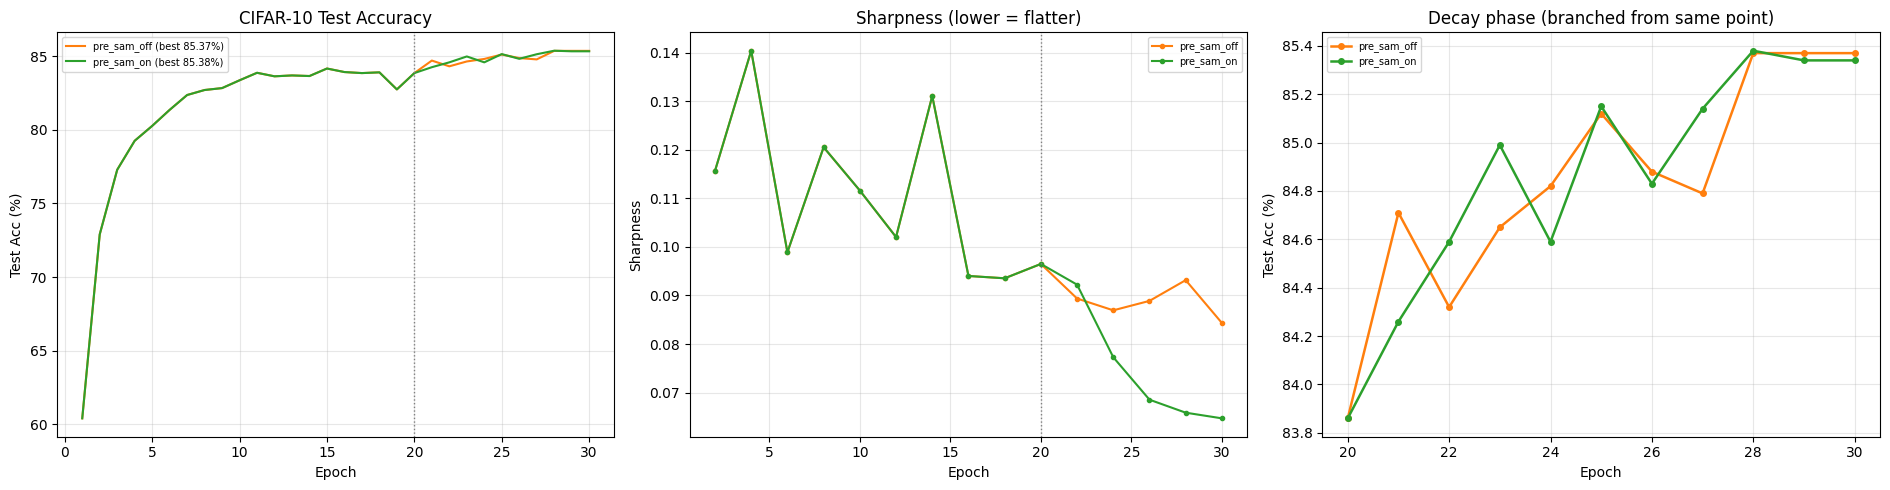

arm                          출발       최종       Δ    Train     Sharp      분
----------------------------------------------------------------------------
pre_sam_off              83.86%   85.37%  +1.51p   95.75%    0.0843    6.0
pre_sam_on               83.86%   85.34%  +1.48p   95.77%    0.0647   11.9
----------------------------------------------------------------------------

※ 같은 arm 접두사(pre/scratch)끼리는 완전히 동일한 지점에서 분기했으므로,
  차이는 오직 SAM 유무에서 비롯됩니다.


In [16]:
# ==========================================
# 9. 결과 비교
# ==========================================
import glob, json
import matplotlib.pyplot as plt

arms = {}
for fp in sorted(glob.glob(os.path.join(SAVE_DIR, 'arm_*.json'))):
    with open(fp, encoding='utf-8') as f:
        rec = json.load(f)
    arms[rec['arm']] = rec

if not arms:
    print("⚠️ 결과가 없습니다. 셀 8을 먼저 실행하세요.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    palette = {'sam_on': 'tab:green', 'sam_off': 'tab:orange'}
    colors = {k: palette['sam_on'] if 'sam_on' in k else palette['sam_off'] for k in arms}
    styles = {k: '-' if k.startswith('pre') else '--' for k in arms}
    stable_end = list(arms.values())[0]['cfg']['total_epochs'] - \
                 list(arms.values())[0]['cfg']['decay_epochs']

    ax = axes[0]
    for k, rec in arms.items():
        ax.plot(rec['history']['epoch'], rec['history']['test_acc'],
                label=f"{k} (best {rec['results']['best_test_acc']:.2f}%)",
                color=colors[k], linestyle=styles[k], linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)')
    ax.set_title('CIFAR-10 Test Accuracy')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[1]
    for k, rec in arms.items():
        ax.plot(rec['sharpness_history']['epoch'], rec['sharpness_history']['sharpness'],
                label=k, color=colors[k], linestyle=styles[k], marker='o',
                markersize=3, linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness')
    ax.set_title('Sharpness (lower = flatter)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[2]
    for k, rec in arms.items():
        ep = rec['history']['epoch'][stable_end-1:]
        ta = rec['history']['test_acc'][stable_end-1:]
        ax.plot(ep, ta, label=k, color=colors[k], linestyle=styles[k],
                marker='o', markersize=4, linewidth=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)')
    ax.set_title('Decay phase (branched from same point)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/vit_branch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{'arm':<22}{'출발':>9}{'최종':>9}{'Δ':>8}{'Train':>9}{'Sharp':>10}{'분':>7}")
    print("-" * 76)
    for k, rec in arms.items():
        r = rec['results']
        d = r['final_test_acc'] - r['decay_start_test_acc']
        print(f"{k:<22}{r['decay_start_test_acc']:>8.2f}%{r['final_test_acc']:>8.2f}%"
              f"{d:>+7.2f}p{r['final_train_acc']:>8.2f}%{r['final_sharpness']:>10.4f}"
              f"{r['decay_time_min']:>7.1f}")
    print("-" * 76)
    print("\n※ 같은 arm 접두사(pre/scratch)끼리는 완전히 동일한 지점에서 분기했으므로,")
    print("  차이는 오직 SAM 유무에서 비롯됩니다.")